Est-ce qu’il y a un effet de lag entre SPY et AAPL ? (Y a-t-il des répercutions des mouvements du prix du SP500 sur le prix d'AAPLe quelques centièmes / dixième de seconde plus tard ? Ou sur le volume ?)


Pour y répondre nous étudierons les variations de prix, la corrélation entre le volume et le spread, la corrélation entre le volume et le prix, sur différentes rolling window, avec et sans lag.



In [320]:
import polars as pl
import datetime as dt
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy.stats import norm
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf

In [321]:
pl.Config.set_tbl_cols(200)               
pl.Config.set_tbl_rows(50)                

polars.config.Config

In [322]:
df_merged_min_trade = pl.read_parquet("../data/clean/merged_1min.parquet")
df_merged_min_trade_normalized = df_merged_min_trade.select(["datetime", "price_AAPL_normalized", "volume_AAPL_normalized", "return_AAPL_normalized", "price_SPY_normalized", "volume_SPY_normalized", "return_SPY_normalized"])

## quelques plots


In [323]:
colors_list = ["blue", "red", "green", "orange", "purple", "brown", "pink", "olive", "cyan"]

def plot_metric(df, metric, title = None, day_plot = False, mean_std_lines = False, colors = None):
    metric = metric.lower()
    metric_cols = [c for c in df.columns if metric in c.lower()]
    if len(metric_cols) == 0:
        print(f"No columns found for metric '{metric}'")
        return

    if colors is None:
        colors = colors_list[:len(metric_cols)]
    elif isinstance(colors, str):
        if len(metric_cols) > 1 :
            colors = colors_list[:len(metric_cols)]
        else :
            colors = [colors]
    elif len(colors) < len(metric_cols):
        colors = colors_list[:len(metric_cols)]

    if title is None and not day_plot:
        title = f"{metric.capitalize()} compared over the whole period"
    elif title is None:
        title = f"{metric.capitalize()} compared"
    plt.figure(figsize=(14,4))
    for col in metric_cols:
        col_label = col.replace("_", " ").replace("normalized", "").replace(metric, "").strip().capitalize()
        plt.plot(df["datetime"], df[col], label=col_label, color=colors[metric_cols.index(col)])
    if mean_std_lines and len(metric_cols) == 1:
        data = df[metric_cols[0]].to_numpy()
        mean = np.nanmean(data)
        std = np.nanstd(data)
        plt.axhline(mean, color='black', label='Mean')
        plt.axhline(mean + std, color='black', linestyle='--', label='Mean + 1 Std Dev')
        plt.axhline(mean - std, color='black', linestyle='--', label='Mean - 1 Std Dev')
    plt.title(title)
    plt.ylabel(f"{metric.replace("_", " ").replace("normalized", "").replace(metric, "").strip().capitalize()} (normalized)")
    plt.legend()
    if day_plot:
        plt.xlabel("Time")
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    else :
        plt.xlabel("Date")
    plt.xticks(rotation=40)
    plt.grid(True, alpha=0.2)
    plt.show()
    return

def plot_metric_day(df, metric, day):
    df_day = df.filter(pl.col("datetime").dt.date() == day)
    title = f"{metric.capitalize()} compared on {day}"
    plot_metric(df_day, metric, title, True)
    return

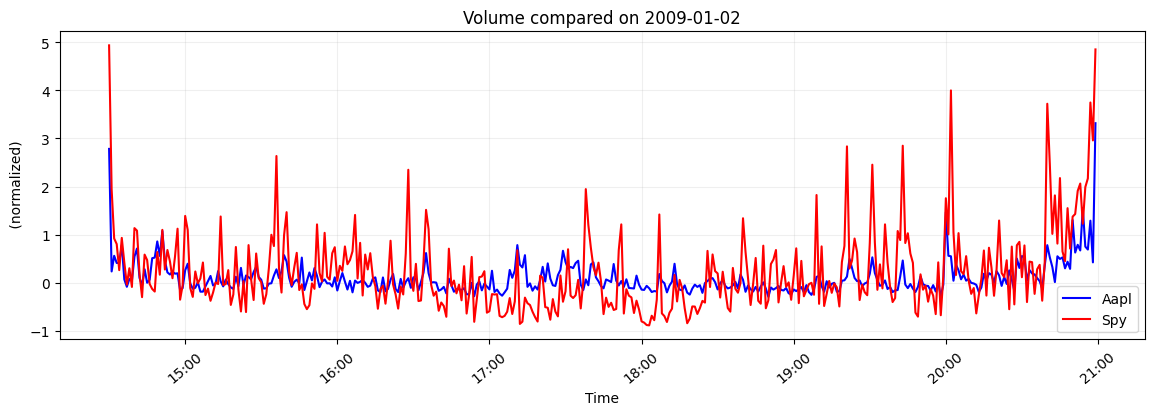

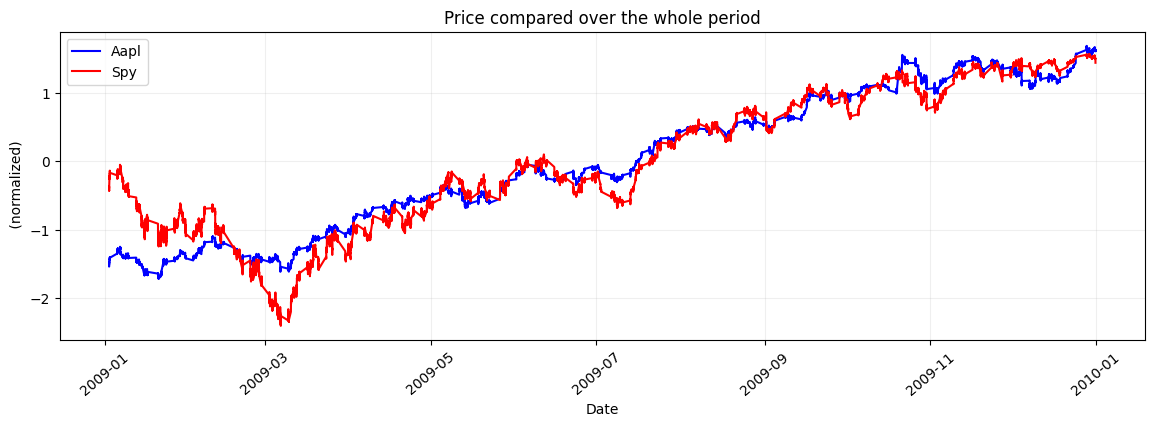

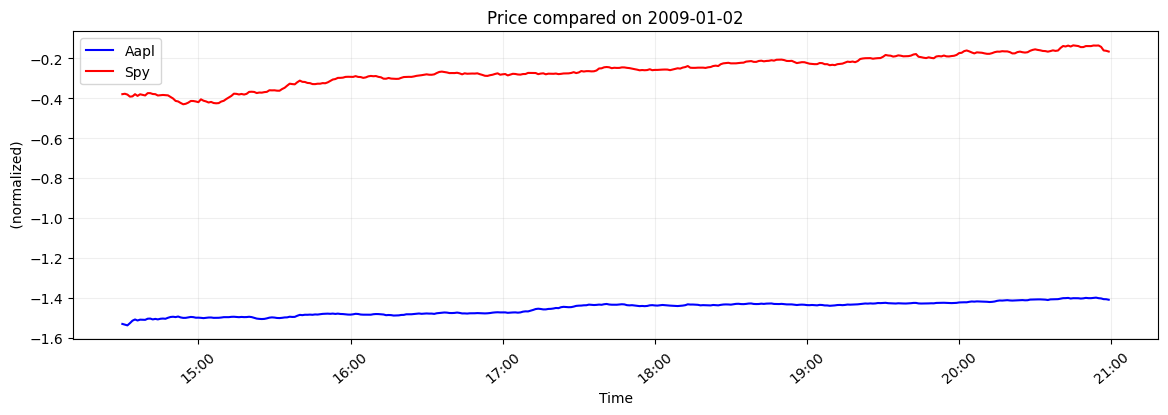

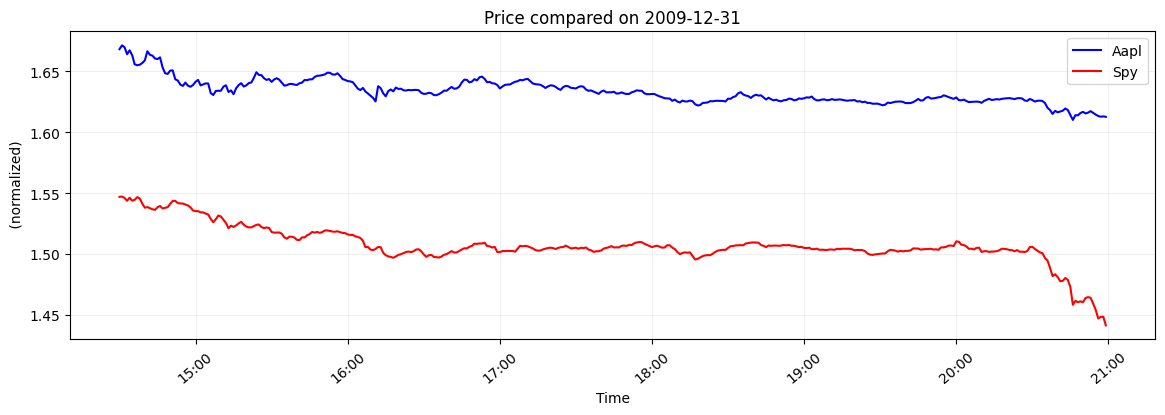

In [324]:
first_day = df_merged_min_trade_normalized["datetime"][0].date()
last_day = df_merged_min_trade_normalized["datetime"][-1].date()

plot_metric_day(df_merged_min_trade_normalized, "volume", first_day)
plot_metric(df_merged_min_trade_normalized, "price")
plot_metric_day(df_merged_min_trade_normalized, "price", first_day)
plot_metric_day(df_merged_min_trade_normalized, "price", last_day)

## return


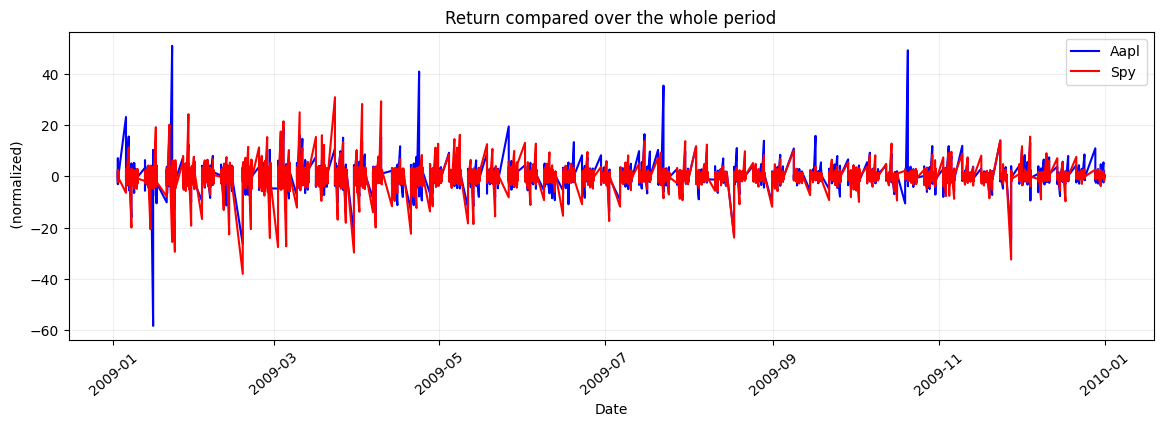

In [325]:
plot_metric(df_merged_min_trade_normalized, "return")

In [326]:
def plot_gaussian_fit(df, metric = None, label = None, nb_bins = 50, coeff = 1.1):
    df = df.to_numpy()
    mu, sigma = np.mean(df), np.std(df)
    color = colors_list[:2]
    plt.figure(figsize=(6,4))
    plt.hist(df, bins=nb_bins, density=True, color=color[0], label="Empirical")
    x_axis = np.linspace(df.min()/coeff, df.max()*coeff, 200)
    plt.plot(x_axis, norm.pdf(x_axis, mu, sigma), color=color[1], label="Gaussian fit")
    if metric is not None and label is not None:
        plt.title(f"Distribution of {label} normalized {metric}s with Gaussian fit")
        plt.xlabel(metric)
    elif label is not None:
        plt.title(f"Distribution of {label} with Gaussian fit")
        plt.xlabel("Value")
    elif metric is not None:
        plt.title(f"Distribution of normalized {metric} with Gaussian fit")
        plt.xlabel(metric)
    else:
        plt.title("Distribution with Gaussian fit")
        plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()
    return

def plot_qq(df, metric=None, label=None):
    plt.figure(figsize=(6,4))
    stats.probplot(df.to_numpy(), dist="norm", plot=plt)
    if metric is not None and label is not None:
        plt.gca().set_title(f"QQ-Plots of {label} normalized {metric} vs Normal Distribution")
    elif label is not None:
        plt.gca().set_title(f"QQ-Plots of {label} vs Normal Distribution")
    elif metric is not None:
        plt.gca().set_title(f"QQ-Plots of normalized {metric} vs Normal Distribution")
    else:
        plt.gca().set_title("QQ-Plots vs Normal Distribution")
    plt.grid(alpha=0.2)
    plt.show()
    return

def plot_ACF(df, lags=10, metric=None, label=None):
    df = df.to_numpy()
    plt.figure(figsize=(6,4))
    plot_acf(df, lags=lags, color=colors_list[0])
    if metric is not None and label is not None:
        plt.title(f"Autocorrelation Function (ACF) of {label} normalized {metric}")
    elif label is not None:
        plt.title(f"Autocorrelation Function (ACF) of {label}")
    elif metric is not None:
        plt.title(f"Autocorrelation Function (ACF) of normalized {metric}")
    else:
        plt.title("Autocorrelation Function (ACF)")
    plt.xlabel("Lags")
    plt.ylabel("ACF")
    plt.grid(alpha=0.2)
    plt.show()
    return

In [ ]:
for col in ["return_AAPL_normalized", "return_SPY_normalized"]:
    label = col.replace("_", " ").replace("normalized", "").replace("return", "").strip().upper()
    metric = "return"
    df_col = df_merged_min_trade_normalized[col]
    plot_gaussian_fit(df_col, metric, label, 75)
    plot_qq(df_col, metric, label)
    plot_ACF(df_col)

## Cross Corellation (with and witout lag)

In [ ]:
def cross_corr_at_lag(df_1, df_2, lag):
    """
    Compute correlation between df_1(t+lag) and df_2(t)
    lag > 0  -> test if df_2 leads df_1
    lag < 0  -> test if df_1 leads df_2
    """
    df_1 = df_1.to_numpy()
    df_2 = df_2.to_numpy()
    if lag > 0:
        return np.corrcoef(df_1[lag:], df_2[:-lag])[0, 1]
    elif lag < 0:
        lag = -lag
        return np.corrcoef(df_1[:-lag], df_2[lag:])[0, 1]
    else:
        return np.corrcoef(df_1, df_2)[0, 1]
    
def plot_cross_corr(df_1, df_2, lags, metric_1 = None, metric_2 = None, label_1="", label_2="", sec = False):
    cc_values = [cross_corr_at_lag(df_1, df_2, lag) for lag in lags]
    plt.figure(figsize=(10,4))
    plt.stem(lags, cc_values, basefmt=" ", linefmt="b-", markerfmt="bo")
    plt.axhline(0, color='blue')
    if metric_1 is None or metric_2 is None:
        plt.title(f"Cross-Correlation between {label_1} and {label_2} at different lags")
    else:
        plt.title(f"Cross-Correlation between {label_1} normalized {metric_1} and {label_2} normalized {metric_2} at different lags")
    if sec:
        plt.xlabel("Lags (seconds)")
    else:
        plt.xlabel("Lags (minutes)")
    plt.ylabel("Cross-Correlation")
    plt.grid(alpha=0.2)
    plt.show()
    return cc_values


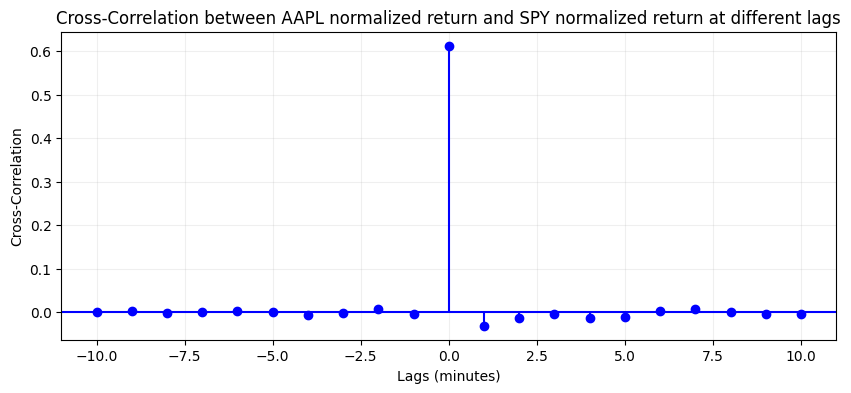

In [ ]:
lags_min = range(-10, 11)  # -10 to +10
_ = plot_cross_corr(df_merged_min_trade_normalized["return_AAPL_normalized"], df_merged_min_trade_normalized["return_SPY_normalized"], lags_min, "return", "return", "AAPL", "SPY")

## Not much things to say in minute -> let's analyse it in secondes 

In [ ]:
df_merged_sec_trade = pl.read_parquet("../data/clean/merged_1sec.parquet")
df_merged_sec_trade_normalized = df_merged_sec_trade.select(["datetime", "price_AAPL_normalized", "volume_AAPL_normalized", "return_AAPL_normalized", "price_SPY_normalized", "volume_SPY_normalized", "return_SPY_normalized"])
print(df_merged_sec_trade_normalized.head())

shape: (5, 7)
┌──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ datetime     ┆ price_AAPL_ ┆ volume_AAPL ┆ return_AAPL ┆ price_SPY_n ┆ volume_SPY_ ┆ return_SPY_ │
│ ---          ┆ normalized  ┆ _normalized ┆ _normalized ┆ ormalized   ┆ normalized  ┆ normalized  │
│ datetime[μs, ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│ America/New_ ┆ f64         ┆ f64         ┆ f64         ┆ f64         ┆ f64         ┆ f64         │
│ York]        ┆             ┆             ┆             ┆             ┆             ┆             │
╞══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 2009-01-02   ┆ -1.325655   ┆ 0.148969    ┆ -3.002701   ┆ -0.162332   ┆ -0.232075   ┆ -0.579949   │
│ 09:30:00 EST ┆             ┆             ┆             ┆             ┆             ┆             │
│ 2009-01-02   ┆ -1.326754   ┆ -0.046839   ┆ -0.335281   ┆ -0.15765    ┆ 0.91

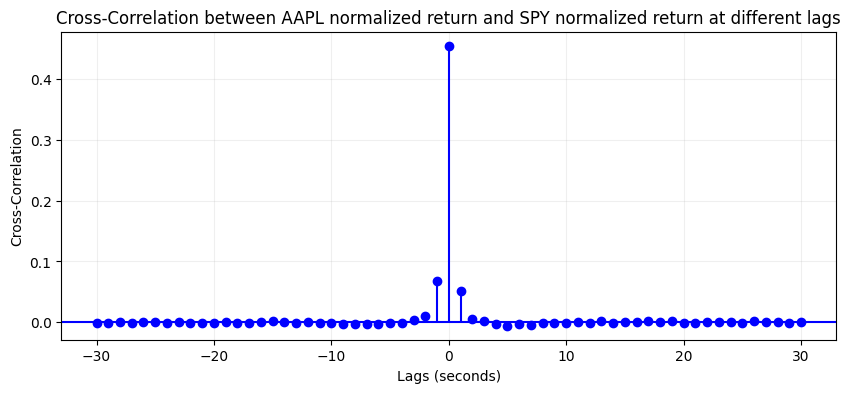

In [ ]:
lags_sec = range(-30, 31)  # -30 to +30
_ = plot_cross_corr(df_merged_sec_trade_normalized["return_AAPL_normalized"], df_merged_sec_trade_normalized["return_SPY_normalized"], lags_sec, "return", "return", "AAPL", "SPY", True)

## Only the first few secondes have non neglegeable correlation

## Relation volume - Price


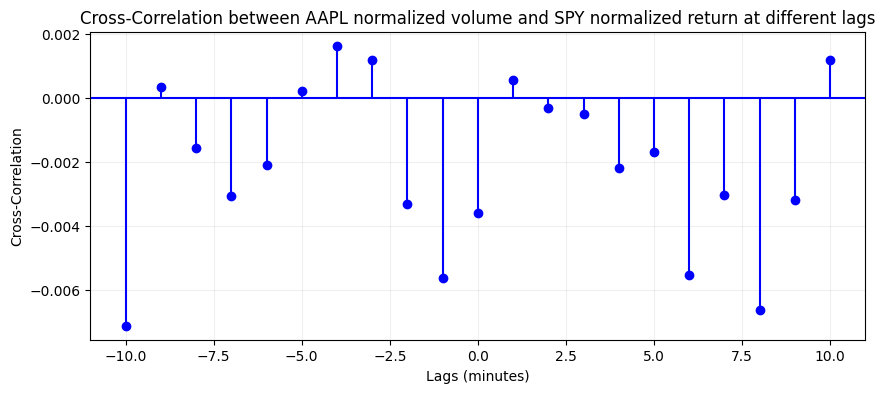

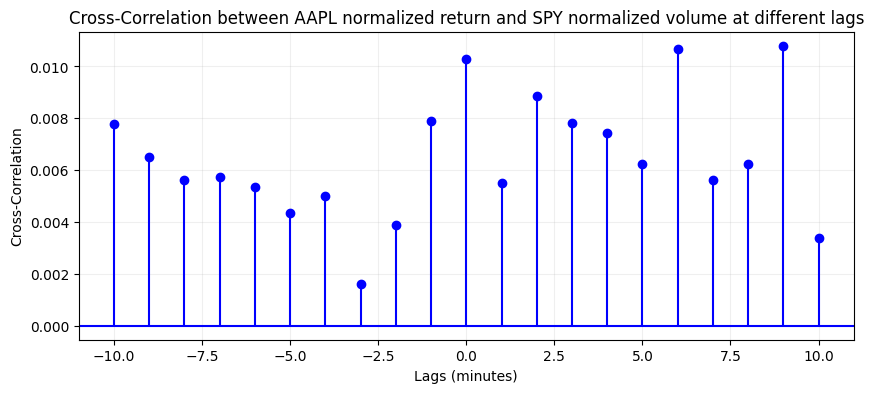

In [ ]:
_ = plot_cross_corr(df_merged_min_trade_normalized["volume_AAPL_normalized"], df_merged_min_trade_normalized["return_SPY_normalized"], lags_min, "volume", "return", "AAPL", "SPY")
_ = plot_cross_corr(df_merged_min_trade_normalized["return_AAPL_normalized"], df_merged_min_trade_normalized["volume_SPY_normalized"], lags_min, "return", "volume", "AAPL", "SPY")

## Rolling Windows

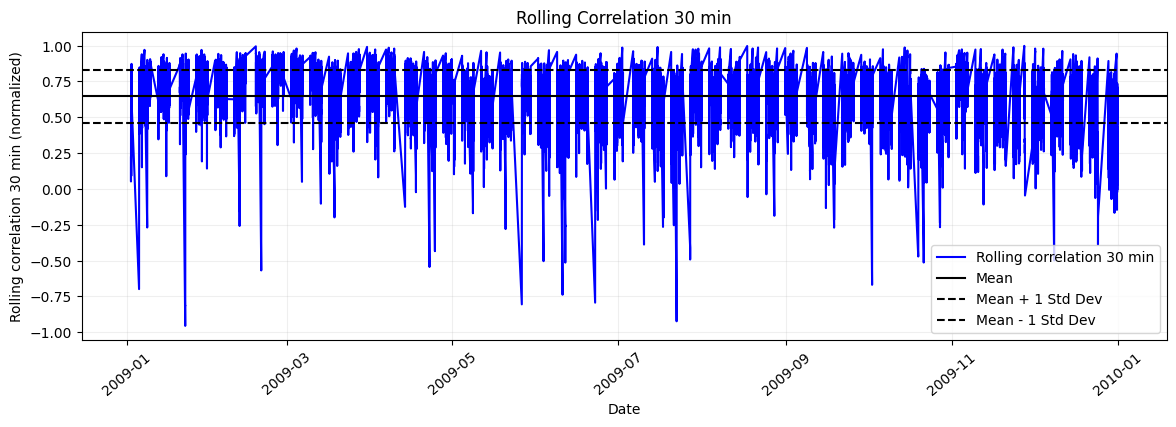

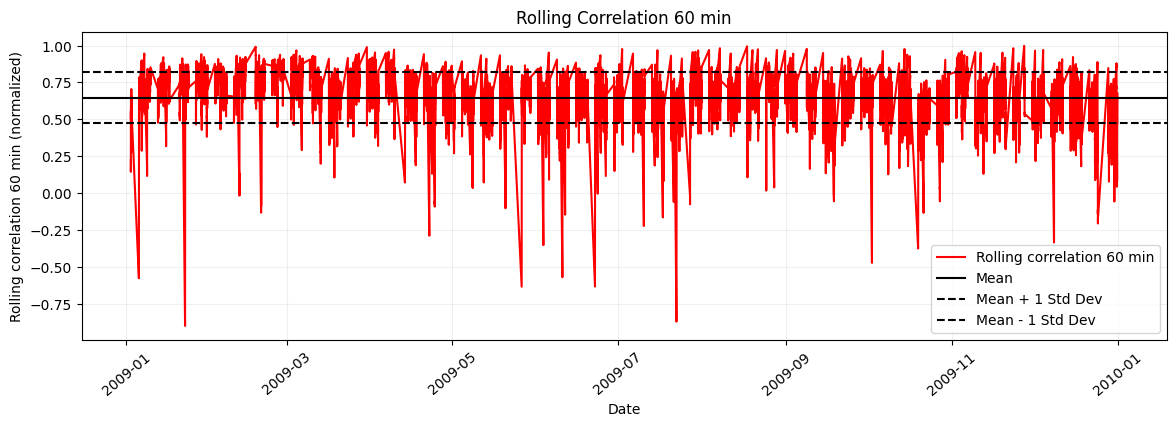

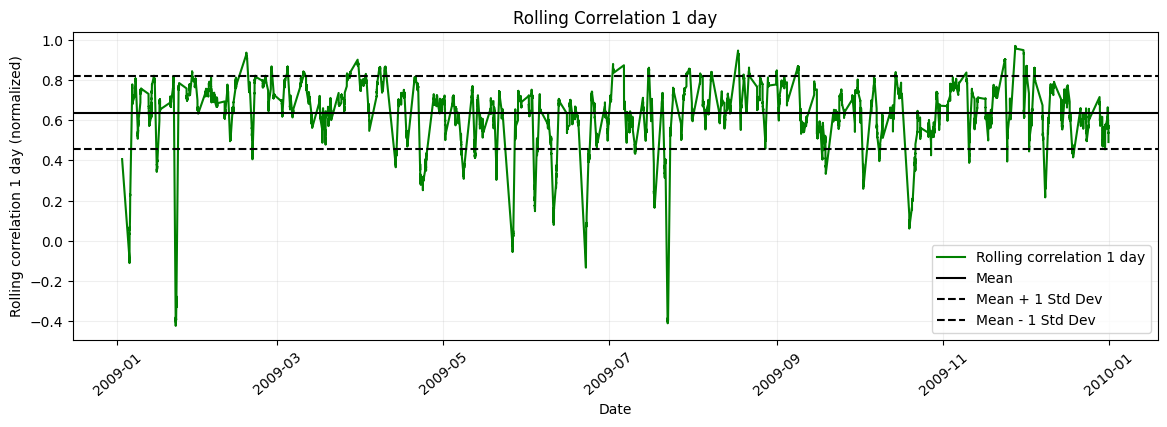

In [ ]:
#Rolling correlations ret_AAPL, ret_SPY (30min, 60min, 1day)
df_roll = (
    df_merged_min_trade_normalized
    .with_columns([
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized"),window_size=30).alias("rolling_correlation_30_min"),
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized"),window_size=60).alias("rolling_correlation_60_min"),
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized"),window_size=390).alias("rolling_correlation_1_day"),
    ])
)

#Rolling lead–lag correlation (lags −1, 0, +1 minute)
df_roll = (
    df_roll
    .with_columns([
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized").shift(-1),window_size=60).alias("lag_m1"),
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized"),window_size=60).alias("lag_0"),
        pl.rolling_corr(pl.col("return_AAPL_normalized"),pl.col("return_SPY_normalized").shift(1),window_size=60).alias("lag_p1"),
    ])
)

plot_metric(df_roll, "rolling_correlation_30_min", title="Rolling Correlation 30 min", mean_std_lines=True, colors=colors_list[0])
plot_metric(df_roll, "rolling_correlation_60_min", title="Rolling Correlation 60 min", mean_std_lines=True, colors=colors_list[1])
plot_metric(df_roll, "rolling_correlation_1_day", title="Rolling Correlation 1 day", mean_std_lines=True, colors=colors_list[2])

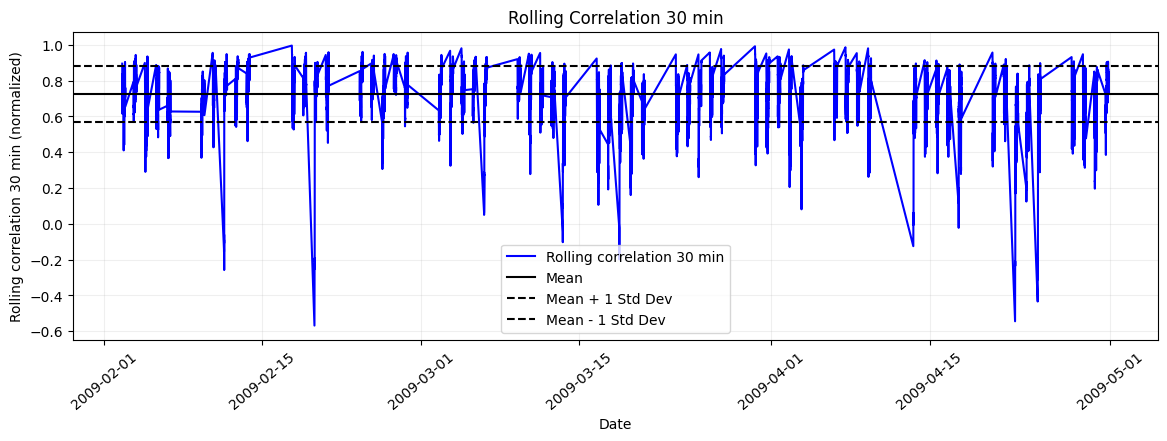

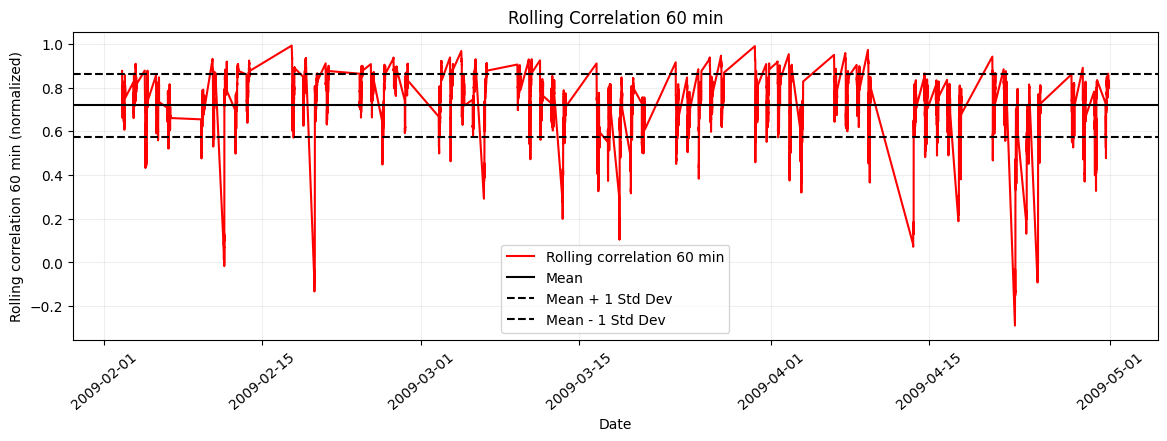

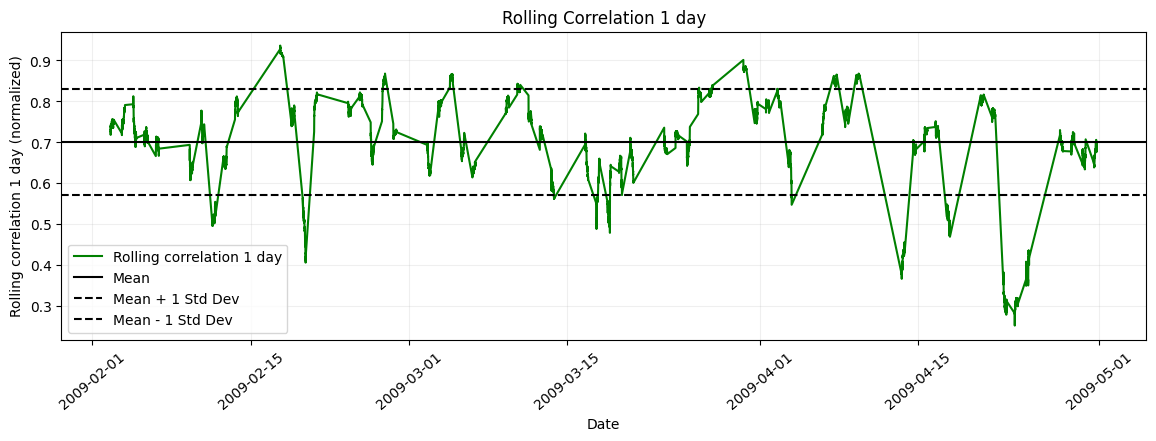

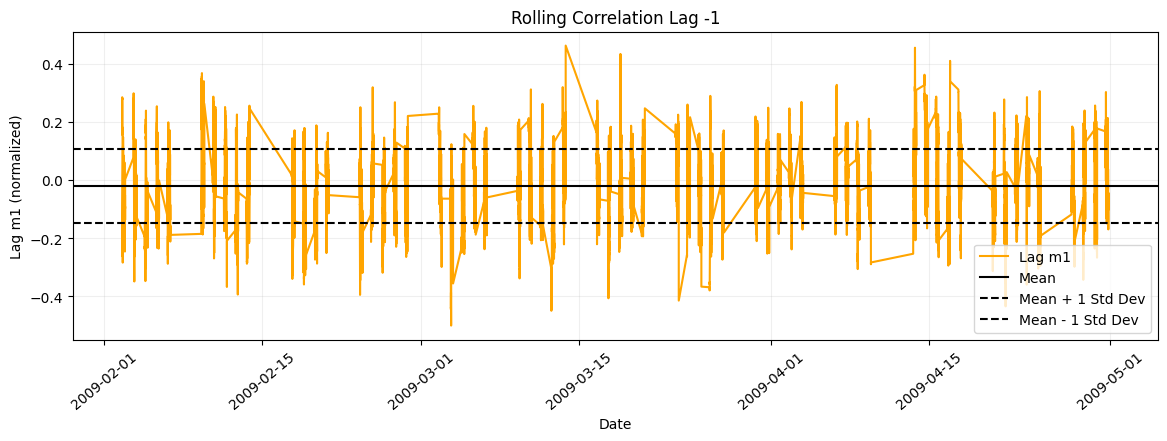

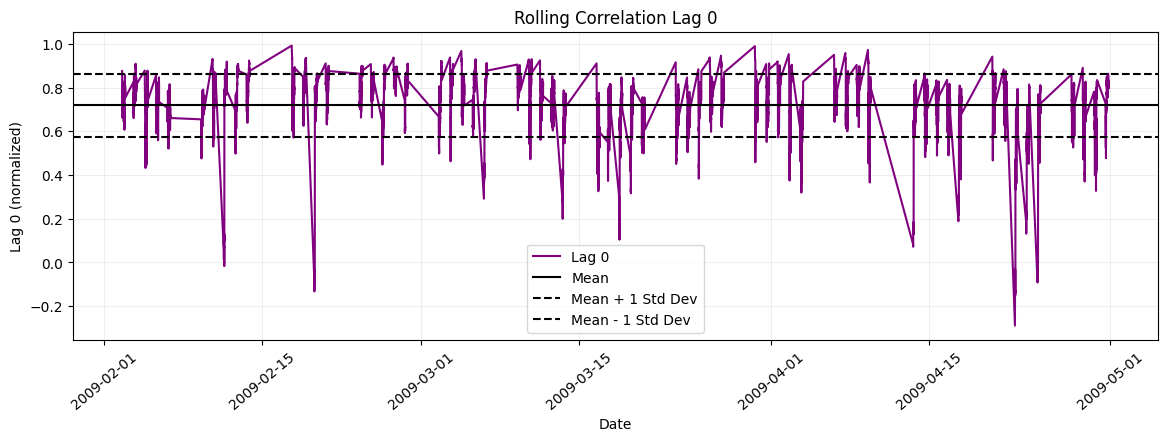

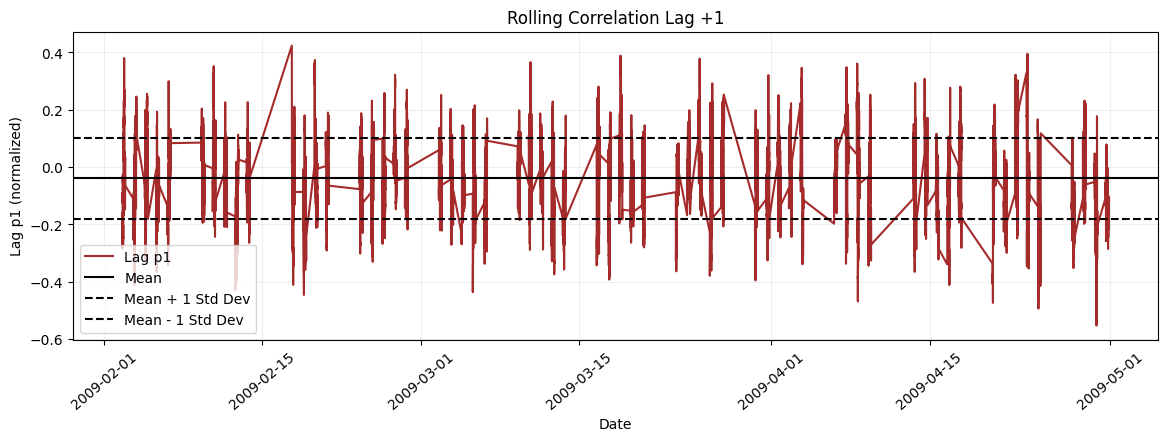

In [ ]:
#On the sub-period, to be easier to see the fluctuations

df_sub = df_roll.filter(
    (pl.col("datetime") >= pl.datetime(2009, 2, 1, time_zone="America/New_York")) &
    (pl.col("datetime") <  pl.datetime(2009, 5, 1, time_zone="America/New_York"))
)

plot_metric(df_sub, "rolling_correlation_30_min", title="Rolling Correlation 30 min", mean_std_lines=True, colors=colors_list[0])
plot_metric(df_sub, "rolling_correlation_60_min", title="Rolling Correlation 60 min", mean_std_lines=True, colors=colors_list[1])
plot_metric(df_sub, "rolling_correlation_1_day", title="Rolling Correlation 1 day", mean_std_lines=True, colors=colors_list[2])

plot_metric(df_sub, "lag_m1", title="Rolling Correlation Lag -1", mean_std_lines=True, colors=colors_list[3])
plot_metric(df_sub, "lag_0", title="Rolling Correlation Lag 0", mean_std_lines=True, colors=colors_list[4])
plot_metric(df_sub, "lag_p1", title="Rolling Correlation Lag +1", mean_std_lines=True, colors=colors_list[5])


## Difference between returns

In [ ]:
df_merged_min_trade_normalized = df_merged_min_trade_normalized.with_columns(
    (pl.col("return_AAPL_normalized") - pl.col("return_SPY_normalized")).alias("diff_normalized_return")
)

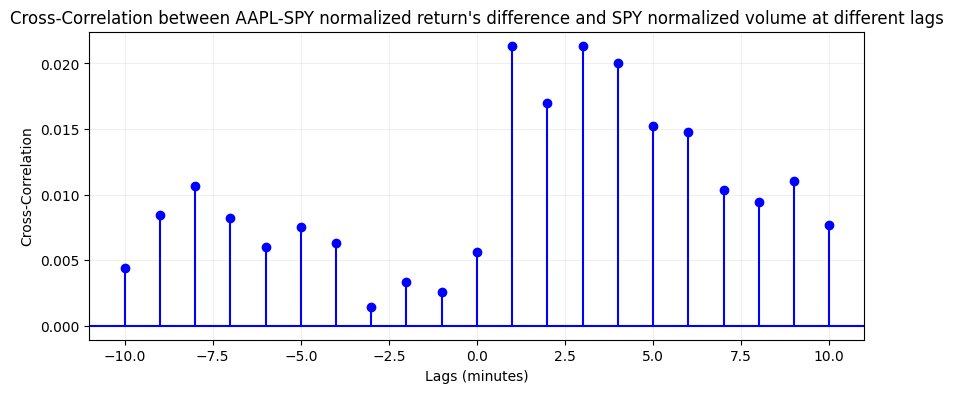

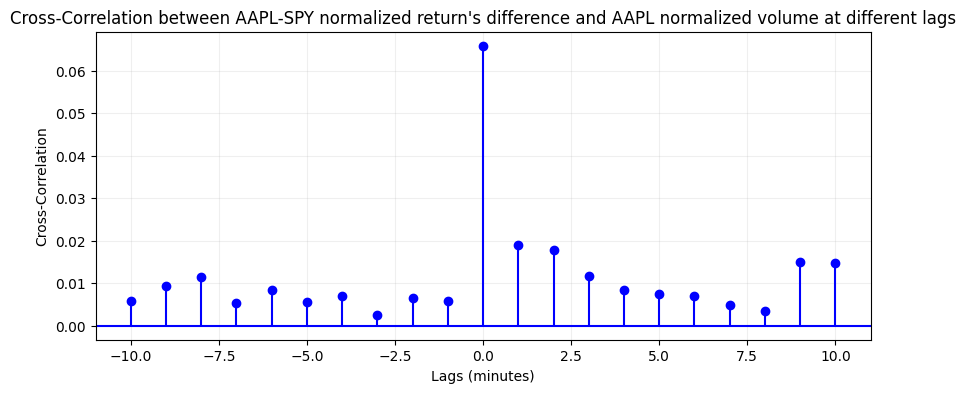

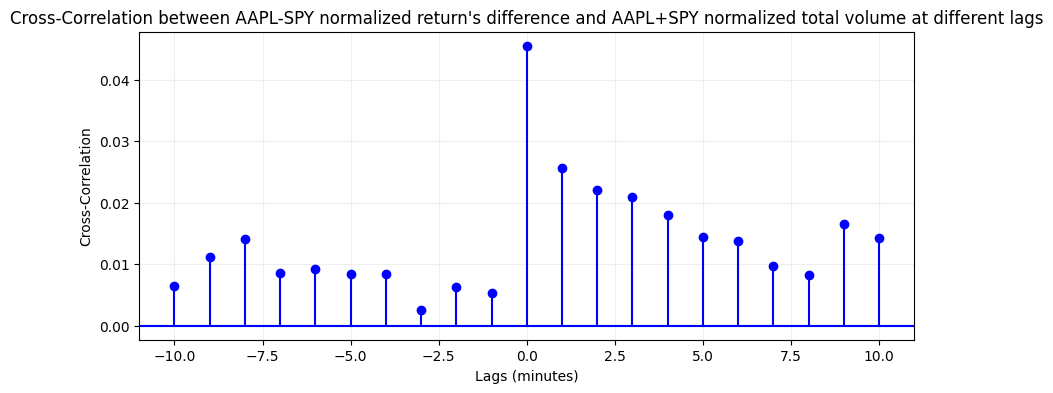

In [ ]:
_ = plot_cross_corr(df_merged_min_trade_normalized["diff_normalized_return"], df_merged_min_trade_normalized["volume_SPY_normalized"], lags_min, "return's difference", "volume", "AAPL-SPY", "SPY")
_ = plot_cross_corr(df_merged_min_trade_normalized["diff_normalized_return"], df_merged_min_trade_normalized["volume_AAPL_normalized"], lags_min, "return's difference", "volume", "AAPL-SPY", "AAPL")
_ = plot_cross_corr(df_merged_min_trade_normalized["diff_normalized_return"], df_merged_min_trade_normalized["volume_AAPL_normalized"] + df_merged_min_trade_normalized["volume_SPY_normalized"], lags_min, "return's difference", "total volume", "AAPL-SPY", "AAPL+SPY")

In [ ]:
df_merged_sec_trade_normalized = df_merged_sec_trade_normalized.with_columns(
    (pl.col("return_AAPL_normalized") - pl.col("return_SPY_normalized")).alias("diff_normalized_return")
)

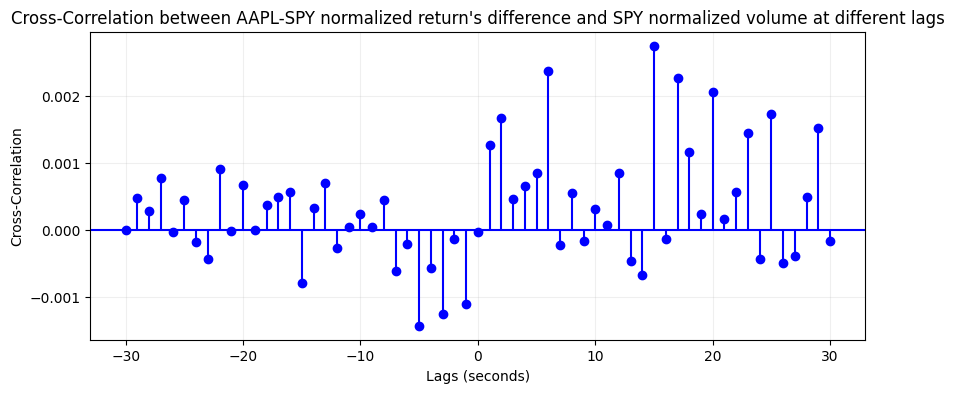

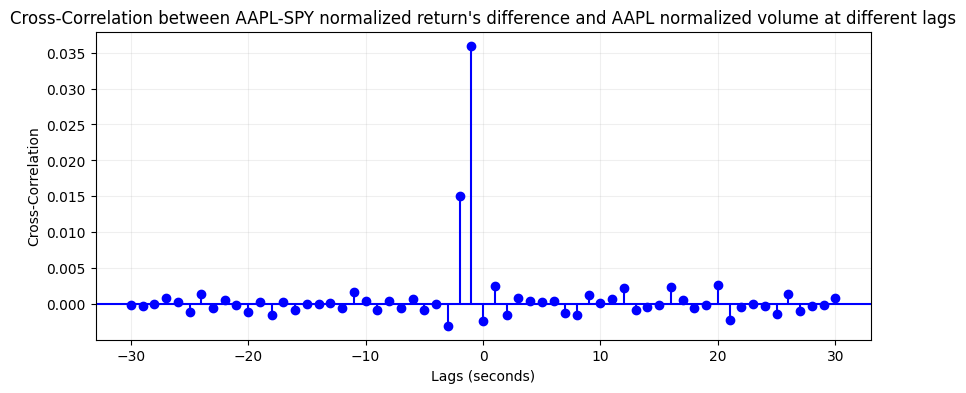

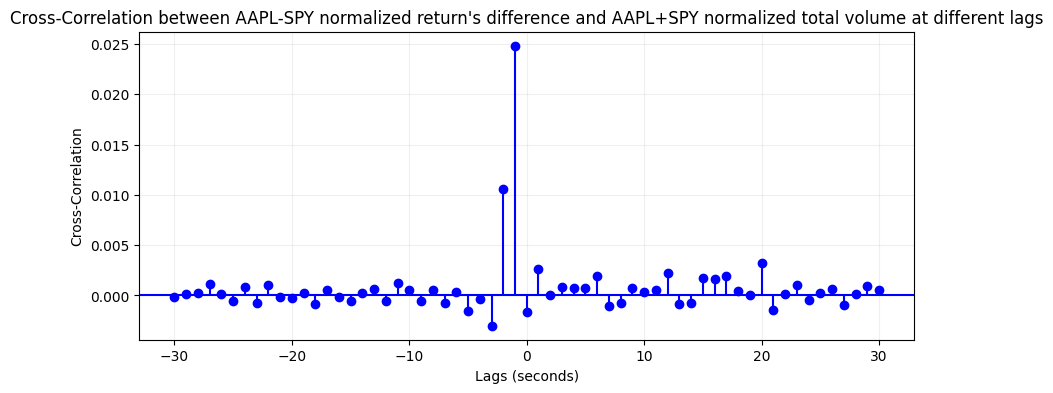

In [ ]:
_ = plot_cross_corr(df_merged_sec_trade_normalized["diff_normalized_return"], df_merged_sec_trade_normalized["volume_SPY_normalized"], lags_sec, "return's difference", "volume", "AAPL-SPY", "SPY", True)
_ = plot_cross_corr(df_merged_sec_trade_normalized["diff_normalized_return"], df_merged_sec_trade_normalized["volume_AAPL_normalized"], lags_sec, "return's difference", "volume", "AAPL-SPY", "AAPL", True)
_ = plot_cross_corr(df_merged_sec_trade_normalized["diff_normalized_return"], df_merged_sec_trade_normalized["volume_AAPL_normalized"] + df_merged_sec_trade_normalized["volume_SPY_normalized"], lags_sec, "return's difference", "total volume", "AAPL-SPY", "AAPL+SPY", True)

## BBO

In [ ]:
df_merged_min_BBO = pl.read_parquet("../data/clean/merged_BBO_1min.parquet")
df_merged_min_BBO_normalized = df_merged_min_BBO.select(["datetime", "bid_price_AAPL_normalized", "bid_volume_AAPL_normalized", "ask_price_AAPL_normalized", "ask_volume_AAPL_normalized", "spread_AAPL_normalized", "bid_price_SPY_normalized", "bid_volume_SPY_normalized", "ask_price_SPY_normalized", "ask_volume_SPY_normalized", "spread_SPY_normalized"])

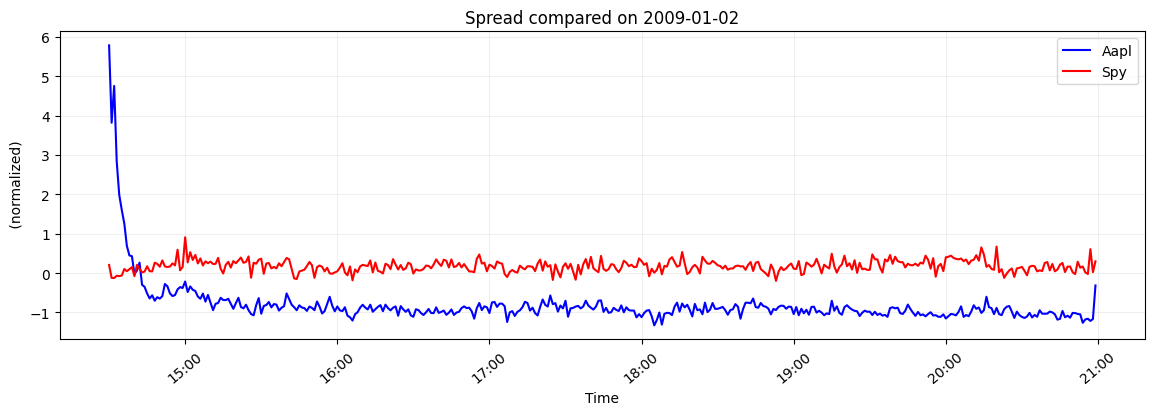

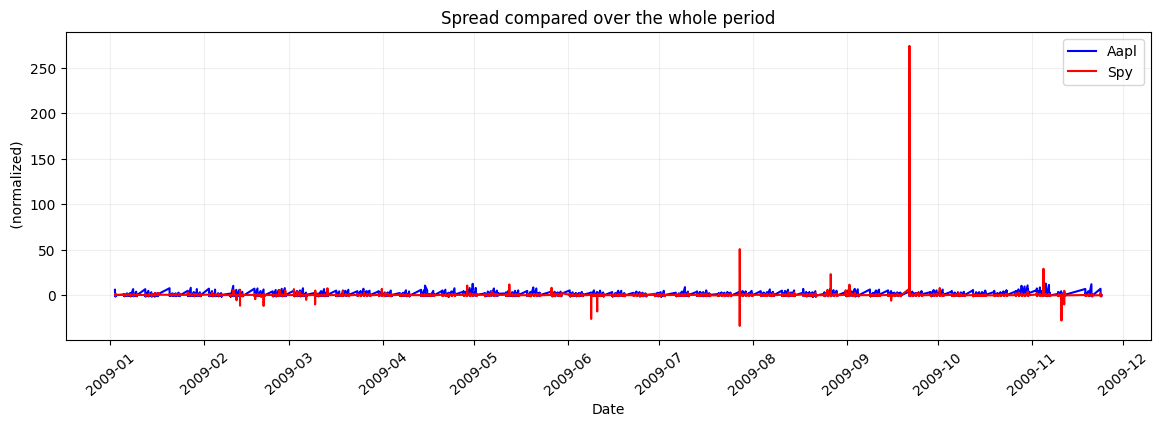

In [ ]:
plot_metric_day(df_merged_min_BBO_normalized, "spread", first_day)
plot_metric(df_merged_min_BBO_normalized, "spread")